In [26]:
# BUSI 3-Class Classification (Normal / Benign / Malignant)
# Strategy for imbalance: Data Augmentation + Alpha-weighted Focal Loss
# Pipeline summary:
# 1. Custom dataset that ignores *_mask.png files
# 2. Stratified train/test split
# 3. Train-time augmentations
# 4. Custom CNN classifier
# 5. Alpha-weighted Focal loss (handles class imbalance at loss level)


In [27]:
import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


In [28]:
# ---------------------------
# Config
# ---------------------------
DATA_ROOT = Path('/kaggle/input/datasets/sabahesaraki/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT')
CLASS_NAMES = ['normal', 'benign', 'malignant']
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()
LR = 5e-4
EPOCHS = 30
FOCAL_GAMMA = 1.0       # lower γ → less suppression of easy benign examples
TEST_RATIO = 0.20
SEED = 42

CHECKPOINT_DIR = Path('./checkpoints_busi_cnn')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


In [29]:
# ---------------------------
# Dataset + split utilities
# ---------------------------
class BUSIDataset(Dataset):
    def __init__(self, root_dir, transform=None, class_to_idx=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.class_to_idx = class_to_idx if class_to_idx is not None else CLASS_TO_IDX

        if not self.root_dir.exists():
            raise FileNotFoundError(f'Root directory not found: {self.root_dir}')

        self.samples = []
        for class_name, label in self.class_to_idx.items():
            class_dir = self.root_dir / class_name
            if not class_dir.exists():
                raise FileNotFoundError(f'Class folder not found: {class_dir}')
            for f in sorted(os.listdir(class_dir)):
                if f.lower().endswith('.png') and '_mask' not in f.lower():
                    self.samples.append((str(class_dir / f), label))

        self.targets = [lbl for _, lbl in self.samples]

    @classmethod
    def from_samples(cls, samples, transform=None):
        obj = object.__new__(cls)
        obj.samples = list(samples)
        obj.targets = [lbl for _, lbl in obj.samples]
        obj.transform = transform
        return obj

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        return image, label


def stratified_split(dataset, test_ratio=0.2, seed=42):
    rng = random.Random(seed)
    per_class = {}
    for i, (_, label) in enumerate(dataset.samples):
        per_class.setdefault(label, []).append(i)

    train_samples, test_samples = [], []
    for cls in sorted(per_class):
        idxs = per_class[cls][:]
        rng.shuffle(idxs)
        n_test = max(1, int(len(idxs) * test_ratio))
        test_samples.extend(dataset.samples[i] for i in idxs[:n_test])
        train_samples.extend(dataset.samples[i] for i in idxs[n_test:])

    rng.shuffle(train_samples)
    rng.shuffle(test_samples)
    return train_samples, test_samples


In [30]:
# ---------------------------
# Transforms + split + loaders
# ---------------------------
train_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
])

full_dataset = BUSIDataset(DATA_ROOT, class_to_idx=CLASS_TO_IDX)
print(f'Total images: {len(full_dataset)}')

train_samples, test_samples = stratified_split(full_dataset, TEST_RATIO, SEED)

train_dataset = BUSIDataset.from_samples(train_samples, transform=train_tfms)
test_dataset  = BUSIDataset.from_samples(test_samples,  transform=eval_tfms)

train_counts = Counter(train_dataset.targets)
print('Train:', {CLASS_NAMES[c]: train_counts[c] for c in range(len(CLASS_NAMES))})
print('Test: ', {CLASS_NAMES[c]: Counter(test_dataset.targets)[c] for c in range(len(CLASS_NAMES))})

loader_kwargs = dict(num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  **loader_kwargs)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)

print(f'Loaders ready | train batches={len(train_loader)}, test batches={len(test_loader)}')


Total images: 780
Train: {'normal': 107, 'benign': 350, 'malignant': 168}
Test:  {'normal': 26, 'benign': 87, 'malignant': 42}
Loaders ready | train batches=20, test batches=5


In [31]:
# Quick sanity check: one training batch
xb, yb = next(iter(train_loader))
print('Batch image shape:', xb.shape)
print('Batch labels shape:', yb.shape)
print('Label counts in sampled batch:', Counter(yb.tolist()))

Batch image shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Label counts in sampled batch: Counter({1: 19, 2: 11, 0: 2})


In [32]:
# ---------------------------
# Model: pretrained ResNet-18 fine-tuned for BUSI
# ---------------------------
def build_model(n_classes, dropout=0.4):
    backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    # replace final FC: 512 → n_classes
    backbone.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(backbone.fc.in_features, n_classes),
    )
    return backbone


In [33]:
# ---------------------------
# Focal loss
# ---------------------------
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction
        if alpha is not None:
            self.register_buffer('alpha', torch.tensor(alpha, dtype=torch.float32))
        else:
            self.alpha = None

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce)
        focal = (1.0 - pt).pow(self.gamma) * ce

        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            focal = alpha_t * focal

        if self.reduction == 'mean':
            return focal.mean()
        if self.reduction == 'sum':
            return focal.sum()
        return focal

def compute_alpha_from_train_counts(train_counts, n_classes):
    counts = torch.tensor([train_counts[c] for c in range(n_classes)], dtype=torch.float32)
    inv = 1.0 / torch.clamp(counts, min=1.0)
    alpha = inv / inv.sum() * n_classes
    return alpha.tolist()

In [34]:
# ---------------------------
# Train + test evaluation methods
# ---------------------------
def train(model, train_loader, criterion, optimizer, epochs, device, save_path=None, scheduler=None):
    model = model.to(device)
    batch_losses = []
    epoch_losses = []

    best_train_loss = float('inf')
    pbar_epochs = tqdm(range(1, epochs + 1), desc='Epochs')
    for epoch in pbar_epochs:
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        pbar_batches = tqdm(train_loader, desc=f'Train {epoch}/{epochs}', leave=False)
        for images, labels in pbar_batches:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            preds = torch.argmax(logits, dim=1)
            running_loss += loss.item() * images.size(0)
            running_correct += (preds == labels).sum().item()
            running_total += images.size(0)

            batch_losses.append(loss.item())
            pbar_batches.set_postfix({
                'batch_loss': f'{loss.item():.4f}',
                'avg_loss': f'{running_loss / max(running_total, 1):.4f}',
                'avg_acc': f'{running_correct / max(running_total, 1):.4f}',
            })

        epoch_loss = running_loss / max(running_total, 1)
        epoch_acc = running_correct / max(running_total, 1)
        epoch_losses.append(epoch_loss)

        if scheduler is not None:
            scheduler.step()
            current_lr = scheduler.get_last_lr()[0]
            print(f'Epoch {epoch:02d}/{epochs} | loss={epoch_loss:.4f} | acc={epoch_acc:.4f} | lr={current_lr:.2e}')
        else:
            print(f'Epoch {epoch:02d}/{epochs} | loss={epoch_loss:.4f} | acc={epoch_acc:.4f}')

        if save_path is not None and epoch_loss < best_train_loss:
            best_train_loss = epoch_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': epoch_loss,
                'class_names': CLASS_NAMES,
            }, save_path)
            print(f'  Saved checkpoint: {save_path}')

    return batch_losses, epoch_losses

@torch.no_grad()
def test_metrics(model, test_loader, device, n_classes):
    model.eval()
    total_correct = 0
    total = 0
    conf = torch.zeros((n_classes, n_classes), dtype=torch.long)

    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        preds = torch.argmax(logits, dim=1)

        total_correct += (preds == labels).sum().item()
        total += images.size(0)

        for t, p in zip(labels.cpu(), preds.cpu()):
            conf[t.long(), p.long()] += 1

    acc = total_correct / max(total, 1)
    return acc, conf


In [35]:
# ---------------------------
# Initialize model configs + train
# ---------------------------
model = build_model(n_classes=len(CLASS_NAMES)).to(device)
alpha = compute_alpha_from_train_counts(train_counts, len(CLASS_NAMES))
criterion = FocalLoss(gamma=FOCAL_GAMMA, alpha=alpha).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
best_path = CHECKPOINT_DIR / 'busi_cnn_best.pt'

print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print('Focal alpha per class:', {CLASS_NAMES[i]: round(alpha[i], 4) for i in range(len(CLASS_NAMES))})

batch_losses, epoch_losses = train(
    model=model,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=EPOCHS,
    device=device,
    save_path=best_path,
    scheduler=scheduler,
)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 201MB/s]

Trainable params: 11,178,051
Focal alpha per class: {'normal': 1.5443, 'benign': 0.4721, 'malignant': 0.9836}


Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

Train 1/30:   0%|          | 0/20 [00:00<?, ?it/s]

...

Epoch 28/30 | loss=0.0147 | acc=0.9872 | lr=6.45e-06


Train 29/30:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 29/30 | loss=0.0111 | acc=0.9888 | lr=2.37e-06


Train 30/30:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 30/30 | loss=0.0140 | acc=0.9872 | lr=1.00e-06


Loaded checkpoint from epoch 27 with train_loss=0.0088
Test accuracy: 0.8516


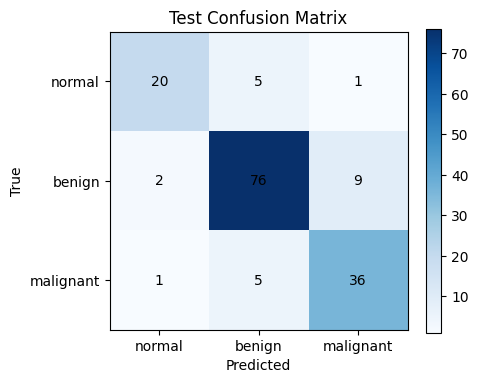

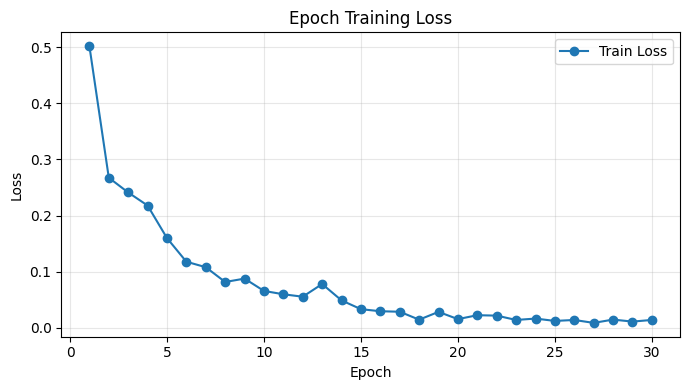

In [36]:
# ---------------------------
# Test accuracy + confusion matrix
# ---------------------------
checkpoint = torch.load(best_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded checkpoint from epoch {checkpoint['epoch']} with train_loss={checkpoint['train_loss']:.4f}")

test_acc, test_conf = test_metrics(
    model=model,
    test_loader=test_loader,
    device=device,
    n_classes=len(CLASS_NAMES),
 )

print(f'Test accuracy: {test_acc:.4f}')

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(test_conf.numpy(), cmap='Blues')
ax.figure.colorbar(im, ax=ax)
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES)
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Test Confusion Matrix')

for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        ax.text(j, i, int(test_conf[i, j]), ha='center', va='center', color='black')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o', label='Train Loss')
plt.title('Epoch Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------
# Per-class precision, recall, F1
# ---------------------------
conf = test_conf.float()
n = len(CLASS_NAMES)

tp = torch.diag(conf)
fp = conf.sum(dim=0) - tp   # predicted as class c but wrong
fn = conf.sum(dim=1) - tp   # actually class c but missed
tn = conf.sum() - tp - fp - fn

precision   = tp / (tp + fp).clamp(min=1e-8)
recall      = tp / (tp + fn).clamp(min=1e-8)
f1          = 2 * precision * recall / (precision + recall).clamp(min=1e-8)
per_cls_acc = (tp + tn) / conf.sum()

print(f"{'Class':<12} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print('-' * 52)
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:<12} {per_cls_acc[i].item():>9.4f} {precision[i].item():>10.4f} {recall[i].item():>8.4f} {f1[i].item():>8.4f}")

print('-' * 52)
print(f"{'Macro avg':<12} {'':>9} {precision.mean().item():>10.4f} {recall.mean().item():>8.4f} {f1.mean().item():>8.4f}")
print(f"\nOverall accuracy: {test_acc:.4f}")


Class         Accuracy  Precision   Recall       F1
----------------------------------------------------
normal          0.9419     0.8696   0.7692   0.8163
benign          0.8645     0.8837   0.8736   0.8786
malignant       0.8968     0.7826   0.8571   0.8182
----------------------------------------------------
Macro avg                  0.8453   0.8333   0.8377

Overall accuracy: 0.8516
